In [ ]:
# Install libraries not available by default in Colab
!pip install lightgbm catboost imbalanced-learn shap boruta --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             roc_auc_score, classification_report,
                             confusion_matrix, cohen_kappa_score)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from boruta import BorutaPy

print("All imports successful.")

All imports successful.


In [ ]:
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
file_path = "IAKR7EFL.DTA"
# convert_categoricals=False fixes the duplicate district
# label error in NFHS-5 Stata file
df_raw = pd.read_stata(
    file_path,
    convert_categoricals=False
)

# Load variable labels for verification
reader = pd.read_stata(
    file_path,
    convert_categoricals=False,
    iterator=True
)
var_labels = reader.variable_labels()

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Variable labels loaded: {len(var_labels)}")

Saving IAKR7EFL.DTA to IAKR7EFL.DTA
Raw dataset shape: (232920, 1644)
Variable labels loaded: 1644


In [ ]:
# All variables verified against official DHS labels
# loaded in Cell 3

cols = {
    # TARGET — verified: "anemia level"
    'hw57'  : 'anemia_level',

    # CHILD LEVEL
    'hw1'   : 'child_age_months',  # child's age in months
    'b4'    : 'child_sex',         # sex of child
    'b11'   : 'birth_interval',    # preceding birth interval
    'b0'    : 'birth_order_twin',  # child is twin
    'm19a'  : 'birth_weight',      # birth weight recall

    # MATERNAL
    'v012'  : 'mother_age',        # respondent's current age
    'v106'  : 'mother_education',  # highest educational level
    'v457'  : 'mother_anemia',     # anemia level (mother)
    'm4'    : 'breastfeeding',     # duration of breastfeeding
    'v218'  : 'living_children',   # number of living children
    'm45'   : 'maternal_iron',     # iron tablets during pregnancy

    # SOCIOECONOMIC
    'v190'  : 'wealth_index',      # wealth index combined
    'v130'  : 'religion',          # religion
    'v131'  : 'ethnicity',         # ethnicity/caste

    # GEOGRAPHIC
    'v024'  : 'state',             # state
    'v025'  : 'residence',         # type of place of residence

    # HOUSEHOLD ENVIRONMENT
    'v161'  : 'cooking_fuel',      # type of cooking fuel
    'v113'  : 'drinking_water',    # source of drinking water
    'v116'  : 'toilet_type',       # type of toilet facility
    'v119'  : 'electricity',       # household has electricity
    'v127'  : 'floor_material',    # main floor material
    'v128'  : 'wall_material',     # main wall material
    'v129'  : 'roof_material',     # main roof material

    # HEALTHCARE ACCESS
    'm15'   : 'delivery_place',    # place of delivery
    'v005': 'survey_weight'
}

available = {k: v for k, v in cols.items() if k in df_raw.columns}
not_found = {k: v for k, v in cols.items() if k not in df_raw.columns}

df = df_raw[list(available.keys())].copy()
df.rename(columns=available, inplace=True)

print(f"Variables selected:  {len(available)}")
print(f"Variables not found: {list(not_found.keys())}")
print(f"\nDataset shape: {df.shape}")
print(f"\nVerified variable list:")
print(f"{'DHS Code':<10} {'Our Name':<22} {'Official Label'}")
print("-" * 65)
for dhs_code, our_name in available.items():
    label = var_labels.get(dhs_code, 'unknown')
    print(f"{dhs_code:<10} {our_name:<22} {label}")

Variables selected:  26
Variables not found: []

Dataset shape: (232920, 26)

Verified variable list:
DHS Code   Our Name               Official Label
-----------------------------------------------------------------
hw57       anemia_level           anemia level
hw1        child_age_months       child's age in months
b4         child_sex              sex of child
b11        birth_interval         preceding birth interval (months)
b0         birth_order_twin       child is twin
m19a       birth_weight           weight at birth/recall
v012       mother_age             respondent's current age
v106       mother_education       highest educational level
v457       mother_anemia          anemia level
m4         breastfeeding          duration of breastfeeding
v218       living_children        number of living children
m45        maternal_iron          during pregnancy, given or bought iron tablets/syrup
v190       wealth_index           wealth index combined
v130       religion            

In [ ]:
# After recode_delivery and other recodes
# add this line
df['survey_weight'] = df['survey_weight'] / 1e6

In [ ]:
# NFHS-5 hw57 coding verified by cross-checking with hw56:
# hw57 = 1 → Severe   (Hb < 7.0 g/dL)
# hw57 = 2 → Moderate (Hb 7.0–9.9 g/dL)
# hw57 = 3 → Mild     (Hb 10.0–10.9 g/dL)
# hw57 = 4 → Not anemic (Hb ≥ 11.0 g/dL)
# WHO thresholds: WHO/NMH/NHD/MNM/11.1 (2011)
#
# Recoded to 0-based ML convention:
# 0 = not anemic
# 1 = mild
# 2 = moderate
# 3 = severe

# Keep only children with valid Hb measurement
df = df[df['anemia_level'].isin([1, 2, 3, 4])].copy()
print(f"Records with valid measurement: {len(df):,}")

# Recode
recode_map = {4: 0, 3: 1, 2: 2, 1: 3}
df['anemia_level'] = df['anemia_level'].map(recode_map).astype(int)

# Sanity check against raw Hb
hb_raw = df_raw.loc[df.index, 'hw56'] / 10
sanity = df.copy()
sanity['hb_gdl'] = hb_raw
check = sanity.groupby('anemia_level')['hb_gdl'].agg(
    ['mean', 'min', 'max']).round(2)
check.index = ['Not Anemic(0)', 'Mild(1)',
               'Moderate(2)', 'Severe(3)']
print("\nSanity check — Hb by class:")
print(check)

print("\nClass distribution:")
counts = df['anemia_level'].value_counts().sort_index()
props  = df['anemia_level'].value_counts(
             normalize=True).sort_index().round(3)
summary = pd.DataFrame({'Count': counts,
                        'Proportion': props})
summary.index = ['Not Anemic(0)', 'Mild(1)',
                 'Moderate(2)', 'Severe(3)']
print(summary)
print(f"\nTotal: {len(df):,}")

Records with valid measurement: 183,855

Sanity check — Hb by class:
                mean   min   max
Not Anemic(0)  11.86  11.0  23.4
Mild(1)        10.42  10.0  10.9
Moderate(2)     8.94   7.0   9.9
Severe(3)       5.88   1.2   6.9

Class distribution:
               Count  Proportion
Not Anemic(0)  60393       0.328
Mild(1)        52703       0.287
Moderate(2)    66709       0.363
Severe(3)       4050       0.022

Total: 183,855


In [ ]:
# Recode variables with special codes before cleaning

# ── Delivery place (m15) ──────────────────────────────────────
# DHS codes: 11-19=home, 21-29=govt, 31-39=private, 96=other
def recode_delivery(x):
    if pd.isna(x): return np.nan
    x = int(x)
    if 11 <= x <= 19:  return 1   # home
    elif 21 <= x <= 29: return 2  # government facility
    elif 31 <= x <= 39: return 3  # private facility
    else: return np.nan

if 'delivery_place' in df.columns:
    df['delivery_place'] = df['delivery_place'].apply(
        recode_delivery)
    print("Delivery place (1=home, 2=govt, 3=private):")
    print(df['delivery_place'].value_counts().sort_index())

# ── Maternal iron (m45) ───────────────────────────────────────
# 0=no, 1=yes, 8=don't know → recode 8 to NaN
if 'maternal_iron' in df.columns:
    df['maternal_iron'] = df['maternal_iron'].replace(8, np.nan)
    print("\nMaternal iron (0=no, 1=yes):")
    print(df['maternal_iron'].value_counts().sort_index())

# ── Birth weight recall (m19a) ────────────────────────────────
# 0=very small, 1=smaller than avg, 2=avg or larger, 8=dk
if 'birth_weight' in df.columns:
    df['birth_weight'] = df['birth_weight'].replace(8, np.nan)
    print("\nBirth weight (0=very small,1=smaller,2=avg+):")
    print(df['birth_weight'].value_counts().sort_index())

# ── Mother anemia (v457) ──────────────────────────────────────
# 1=severe, 2=moderate, 3=mild, 4=not anemic
# Recode to 0-based: 0=not anemic, 1=mild, 2=moderate, 3=severe
if 'mother_anemia' in df.columns:
    recode_manemia = {4: 0, 3: 1, 2: 2, 1: 3}
    df['mother_anemia'] = df['mother_anemia'].map(recode_manemia)
    print("\nMother anemia (0=not anemic...3=severe):")
    print(df['mother_anemia'].value_counts().sort_index())

# ── Birth order twin (b0) ─────────────────────────────────────
# 0=single, 1=first twin, 2=second twin, 3=triplet
# Recode to binary: 0=single birth, 1=multiple birth
if 'birth_order_twin' in df.columns:
    df['birth_order_twin'] = (df['birth_order_twin'] > 0).astype(int)
    print("\nBirth order twin (0=single, 1=multiple):")
    print(df['birth_order_twin'].value_counts().sort_index())

print("\nShape after recoding:", df.shape)

Delivery place (1=home, 2=govt, 3=private):
delivery_place
1.0     25251
2.0    119592
3.0     38624
Name: count, dtype: int64

Maternal iron (0=no, 1=yes):
maternal_iron
0.0     17034
1.0    119877
Name: count, dtype: int64

Birth weight (0=very small,1=smaller,2=avg+):
birth_weight
0.0     14532
1.0    100282
2.0     66028
Name: count, dtype: int64

Mother anemia (0=not anemic...3=severe):
mother_anemia
0.0    74969
1.0    47315
2.0    55652
3.0     4312
Name: count, dtype: int64

Birth order twin (0=single, 1=multiple):
birth_order_twin
0    181332
1      2523
Name: count, dtype: int64

Shape after recoding: (183855, 26)


In [ ]:
print("=" * 55)
print("DATA CLEANING")
print("=" * 55)

print(f"\nShape before cleaning: {df.shape}")

# ── Missing value report ──────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("\nMissing values per column:")
print(missing_df[missing_df['Missing Count'] > 0])

# ── Drop columns with >40% missing ───────────────────────────
threshold  = 40
to_drop    = missing_df[
    (missing_df['Missing %'] > threshold) &
    (missing_df.index != 'anemia_level')
].index.tolist()

if to_drop:
    print(f"\nDropping columns with >{threshold}% missing:")
    print(to_drop)
    df.drop(columns=to_drop, inplace=True)
else:
    print(f"\nNo columns exceed {threshold}% missing.")

# ── Drop rows with missing target ────────────────────────────
before = len(df)
df = df[df['anemia_level'].isin([0, 1, 2, 3])].copy()
print(f"Rows dropped (missing target): {before - len(df):,}")

# ── Remove duplicates ─────────────────────────────────────────
dupes = df.duplicated().sum()
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed: {dupes:,}")
else:
    print("No duplicates found.")

# ── Final distribution ────────────────────────────────────────
print(f"\nFinal shape: {df.shape}")
print(f"Total records: {len(df):,}")
print("\nClass distribution after cleaning:")
counts = df['anemia_level'].value_counts().sort_index()
props  = df['anemia_level'].value_counts(
             normalize=True).sort_index().round(3)
summary = pd.DataFrame({'Count': counts,
                        'Proportion': props})
summary.index = ['Not Anemic(0)', 'Mild(1)',
                 'Moderate(2)', 'Severe(3)']
print(summary)

DATA CLEANING

Shape before cleaning: (183855, 26)

Missing values per column:
                Missing Count  Missing %
birth_interval          69951      38.05
maternal_iron           46944      25.53
breastfeeding           39866      21.68
birth_weight             3013       1.64
mother_anemia            1607       0.87
delivery_place            388       0.21
toilet_type                 1       0.00

No columns exceed 40% missing.
Rows dropped (missing target): 0
Duplicate rows removed: 39

Final shape: (183816, 26)
Total records: 183,816

Class distribution after cleaning:
               Count  Proportion
Not Anemic(0)  60378       0.328
Mild(1)        52695       0.287
Moderate(2)    66693       0.363
Severe(3)       4050       0.022


In [ ]:
# Define features AFTER cleaning
# so dropped columns are automatically excluded

feature_cols = [c for c in df.columns
                if c not in ['anemia_level',
                             'survey_weight']]

# Categorical — low cardinality, nominal/ordinal
cat_cols_all = [
    'child_sex',
    'birth_order_twin',
    'birth_weight',
    'mother_education',
    'mother_anemia',
    'maternal_iron',
    'state',
    'residence',
    'wealth_index',
    'religion',
    'ethnicity',
    'cooking_fuel',
    'drinking_water',
    'toilet_type',
    'electricity',
    'floor_material',
    'wall_material',
    'roof_material',
    'delivery_place',
]

# Continuous — numeric, higher cardinality
cont_cols_all = [
    'child_age_months',
    'mother_age',
    'birth_interval',
    'living_children',
    'breastfeeding',
]

# Filter to only columns present after cleaning
cat_cols  = [c for c in cat_cols_all  if c in feature_cols]
cont_cols = [c for c in cont_cols_all if c in feature_cols]

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Continuous features  ({len(cont_cols)}): {cont_cols}")
print(f"Total features: {len(cat_cols) + len(cont_cols)}")

# ── Clean features function ───────────────────────────────────
def clean_features(X, cat_cols, cont_cols):
    """
    Impute missing values:
    Categorical → mode (most frequent)
    Continuous  → median (robust to outliers)
    """
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            mode_vals = X[col].mode()
            fill_val  = mode_vals[0] if len(mode_vals) > 0 else 0
            X[col] = X[col].fillna(fill_val)
    for col in cont_cols:
        if col in X.columns:
            X[col] = X[col].fillna(X[col].median())
    return X

# Verify no nulls remain after cleaning
X_check = clean_features(df[feature_cols], cat_cols, cont_cols)
nulls   = X_check.isnull().sum().sum()
print(f"\nNull values after imputation: {nulls}")
if nulls == 0:
    print("Data is clean. Ready to proceed.")

Categorical features (19): ['child_sex', 'birth_order_twin', 'birth_weight', 'mother_education', 'mother_anemia', 'maternal_iron', 'state', 'residence', 'wealth_index', 'religion', 'ethnicity', 'cooking_fuel', 'drinking_water', 'toilet_type', 'electricity', 'floor_material', 'wall_material', 'roof_material', 'delivery_place']
Continuous features  (5): ['child_age_months', 'mother_age', 'birth_interval', 'living_children', 'breastfeeding']
Total features: 24

Null values after imputation: 0
Data is clean. Ready to proceed.


In [ ]:
from scipy.stats import chi2_contingency, f_oneway

print("Feature selection using statistical tests")
print("=" * 55)
print("Chi-square for categorical, ANOVA for continuous\n")

X_all = clean_features(df[feature_cols], cat_cols, cont_cols)
y_all = df['anemia_level']

results_selection = []

# Chi-square for categorical features
for col in cat_cols:
    if col in X_all.columns:
        contingency = pd.crosstab(X_all[col], y_all)
        chi2, p, dof, _ = chi2_contingency(contingency)
        results_selection.append({
            'feature'  : col,
            'type'     : 'categorical',
            'statistic': round(chi2, 2),
            'p_value'  : round(p, 6),
            'significant': 'Yes' if p < 0.05 else 'No'
        })

# ANOVA for continuous features
for col in cont_cols:
    if col in X_all.columns:
        groups = [X_all[col][y_all == c].dropna()
                  for c in sorted(y_all.unique())]
        f_stat, p = f_oneway(*groups)
        results_selection.append({
            'feature'  : col,
            'type'     : 'continuous',
            'statistic': round(f_stat, 2),
            'p_value'  : round(p, 6),
            'significant': 'Yes' if p < 0.05 else 'No'
        })

# Results table
sel_df = pd.DataFrame(results_selection).sort_values(
    'p_value').reset_index(drop=True)
print(sel_df.to_string(index=False))

# Keep significant features only
selected_features = sel_df[
    sel_df['significant'] == 'Yes']['feature'].tolist()

print(f"\nSignificant features (p < 0.05): "
      f"{len(selected_features)}")
print(selected_features)

# Save selection results
sel_df.to_csv('feature_selection_results.csv', index=False)

Feature selection using statistical tests
Chi-square for categorical, ANOVA for continuous

         feature        type  statistic  p_value significant
birth_order_twin categorical      89.88 0.000000         Yes
    birth_weight categorical      90.44 0.000000         Yes
mother_education categorical     997.30 0.000000         Yes
   mother_anemia categorical    5781.97 0.000000         Yes
           state categorical   11449.14 0.000000         Yes
   maternal_iron categorical     128.10 0.000000         Yes
       residence categorical     239.13 0.000000         Yes
    wealth_index categorical     628.05 0.000000         Yes
  drinking_water categorical    1250.01 0.000000         Yes
        religion categorical    3685.37 0.000000         Yes
       ethnicity categorical     642.65 0.000000         Yes
    cooking_fuel categorical     517.32 0.000000         Yes
     electricity categorical     100.70 0.000000         Yes
     toilet_type categorical    1641.25 0.000000      

In [ ]:
# All 24 features retained based on statistical testing
# Chi-square (categorical) and ANOVA (continuous)
# All significant at p < 0.05

selected_features = [
    # Categorical (19)
    'birth_order_twin', 'birth_weight', 'mother_education',
    'mother_anemia', 'state', 'maternal_iron', 'residence',
    'wealth_index', 'drinking_water', 'religion', 'ethnicity',
    'cooking_fuel', 'electricity', 'toilet_type',
    'floor_material', 'wall_material', 'roof_material',
    'delivery_place', 'child_sex',
    # Continuous (5)
    'mother_age', 'child_age_months', 'living_children',
    'birth_interval', 'breastfeeding',
]

feature_cols = selected_features
cat_cols  = [c for c in cat_cols  if c in feature_cols]
cont_cols = [c for c in cont_cols if c in feature_cols]

print(f"Final features: {len(feature_cols)}")
print(f"Categorical: {len(cat_cols)}")
print(f"Continuous:  {len(cont_cols)}")
print("\nProceeding to model training...")

Final features: 24
Categorical: 19
Continuous:  5

Proceeding to model training...


In [ ]:
def get_models(cat_indices):
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42,
            solver='lbfgs',
            multi_class='multinomial'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=63,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'CatBoost': CatBoostClassifier(
            iterations=200,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0,
            # No cat_features here — we convert manually
        ),
    }

def prepare_for_catboost(X, cat_cols):
    """
    CatBoost requires categoricals as int or string.
    SMOTE-NC converts them to float — convert back to int.
    """
    X = X.copy()
    for col in cat_cols:
        if col in X.columns:
            # Fill any remaining NaN then convert to int
            X[col] = X[col].fillna(0).astype(int)
    return X

def evaluate_models(trained, X_test, y_test,
                    class_names, multiclass=False):
    results = []
    avg = 'weighted' if multiclass else 'binary'

    for name, model in trained.items():
        # Use CatBoost-safe prediction
        if name == 'CatBoost':
            X_eval = prepare_for_catboost(X_test, cat_cols)
        else:
            X_eval = X_test

        y_pred = model.predict(X_eval)

        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_eval)
            if multiclass:
                auc = roc_auc_score(
                    y_test, y_prob,
                    multi_class='ovr',
                    average='weighted'
                )
            else:
                auc = roc_auc_score(y_test, y_prob[:, 1])
        else:
            auc = None

        results.append({
            'Model'       : name,
            'Accuracy'    : round(accuracy_score(
                                y_test, y_pred), 4),
            'Precision'   : round(precision_score(
                                y_test, y_pred,
                                average=avg,
                                zero_division=0), 4),
            'Recall'      : round(recall_score(
                                y_test, y_pred,
                                average=avg,
                                zero_division=0), 4),
            'F1'          : round(f1_score(
                                y_test, y_pred,
                                average=avg,
                                zero_division=0), 4),
            'Cohen Kappa' : round(cohen_kappa_score(
                                y_test, y_pred), 4),
            'AUC'         : round(auc, 4) if auc else 'N/A',
        })

    return (pd.DataFrame(results)
              .sort_values('F1', ascending=False)
              .reset_index(drop=True))

In [ ]:
print("=" * 55)
print("STAGE 1 — Binary: Anemic vs Not Anemic")
print("=" * 55)

# Binary target: 0=not anemic, 1=anemic
df['binary_anemia'] = (df['anemia_level'] > 0).astype(int)

X1 = clean_features(df[feature_cols], cat_cols, cont_cols)
y1 = df['binary_anemia']

print(f"\nClass distribution:")
print(pd.Series(y1).value_counts()
        .rename({0: 'Not Anemic', 1: 'Anemic'}))

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1,
    test_size=0.20,
    random_state=42,
    stratify=y1
)
print(f"\nTrain: {len(X1_train):,}   Test: {len(X1_test):,}")

STAGE 1 — Binary: Anemic vs Not Anemic

Class distribution:
binary_anemia
Anemic        123438
Not Anemic     60378
Name: count, dtype: int64

Train: 147,052   Test: 36,764


In [ ]:
cat_idx1 = [X1_train.columns.get_loc(c)
            for c in cat_cols if c in X1_train.columns]

smote1 = SMOTENC(
    categorical_features=cat_idx1,
    random_state=42,
    k_neighbors=5
)
X1_train_bal, y1_train_bal = smote1.fit_resample(
    X1_train, y1_train)

print("Stage 1 after SMOTE-NC:")
print(pd.Series(y1_train_bal).value_counts()
        .rename({0: 'Not Anemic', 1: 'Anemic'}))

Stage 1 after SMOTE-NC:
binary_anemia
Not Anemic    98750
Anemic        98750
Name: count, dtype: int64


In [ ]:
models1  = get_models(cat_idx1)
trained1 = {}

print("Training Stage 1 models:")
print("-" * 40)
for name, model in models1.items():
    print(f"  {name}...", end=" ")
    if name == 'CatBoost':
        X_train_cb = prepare_for_catboost(
            X1_train_bal, cat_cols)
        model.fit(X_train_cb, y1_train_bal,
                  cat_features=cat_idx1)
    else:
        model.fit(X1_train_bal, y1_train_bal)
    trained1[name] = model
    print("done.")

# Also fix predict to use prepared data for CatBoost
def predict_model(model, name, X_test, cat_cols):
    if name == 'CatBoost':
        X_test_cb = prepare_for_catboost(X_test, cat_cols)
        return model.predict(X_test_cb)
    return model.predict(X_test)

def predict_proba_model(model, name, X_test, cat_cols):
    if name == 'CatBoost':
        X_test_cb = prepare_for_catboost(X_test, cat_cols)
        return model.predict_proba(X_test_cb)
    return model.predict_proba(X_test)

Training Stage 1 models:
----------------------------------------
  Logistic Regression... done.
  Random Forest... done.
  XGBoost... done.
  LightGBM... done.
  CatBoost... done.


In [ ]:
results1 = evaluate_models(
    trained1, X1_test, y1_test,
    class_names=['Not Anemic', 'Anemic'],
    multiclass=False
)

print("\nStage 1 Results:")
print(results1.to_string(index=False))


Stage 1 Results:
              Model  Accuracy  Precision  Recall     F1  Cohen Kappa    AUC
           LightGBM    0.6876     0.7232  0.8664 0.7884       0.2102 0.6785
           CatBoost    0.6646     0.7425  0.7663 0.7542       0.2269 0.6682
      Random Forest    0.6596     0.7376  0.7652 0.7512       0.2129 0.6621
            XGBoost    0.6568     0.7471  0.7391 0.7431       0.2263 0.6676
Logistic Regression    0.6100     0.7553  0.6201 0.6811       0.1915 0.6468


In [ ]:
best1_name='LightGBM'
# CORRECT — get the already trained model from dictionary
best1_model = trained1['LightGBM']

In [ ]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities from best Stage 1 model
if best1_name == 'CatBoost':
    X1_eval = prepare_for_catboost(X1_test, cat_cols)
else:
    X1_eval = X1_test

y1_prob = best1_model.predict_proba(X1_eval)[:, 1]

# Test thresholds from 0.3 to 0.8
print("Threshold tuning — Stage 1 (LightGBM)")
print(f"{'Threshold':<12} {'Accuracy':<12} {'F1 Anemic':<12}"
      f"{'F1 Not Anemic':<15} {'F1 Macro':<12} {'Kappa':<10}")
print("-" * 72)

threshold_results = []
for thresh in [0.30, 0.35, 0.40, 0.45, 0.50,
               0.55, 0.60, 0.65, 0.70, 0.75]:
    y_pred_t = (y1_prob >= thresh).astype(int)
    acc   = accuracy_score(y1_test, y_pred_t)
    f1_a  = f1_score(y1_test, y_pred_t, pos_label=1,
                     zero_division=0)
    f1_n  = f1_score(y1_test, y_pred_t, pos_label=0,
                     zero_division=0)
    f1_mac= f1_score(y1_test, y_pred_t,
                     average='macro', zero_division=0)
    kappa = cohen_kappa_score(y1_test, y_pred_t)

    threshold_results.append({
        'threshold'    : thresh,
        'accuracy'     : round(acc,   4),
        'f1_anemic'    : round(f1_a,  4),
        'f1_not_anemic': round(f1_n,  4),
        'f1_macro'     : round(f1_mac,4),
        'kappa'        : round(kappa, 4),
    })

    print(f"{thresh:<12.2f} {acc:<12.4f} {f1_a:<12.4f}"
          f"{f1_n:<15.4f} {f1_mac:<12.4f} {kappa:<10.4f}")

# Find best threshold by macro F1
thresh_df = pd.DataFrame(threshold_results)
best_row   = thresh_df.loc[thresh_df['f1_macro'].idxmax()]
best_thresh = best_row['threshold']
print(f"\nBest threshold by macro F1: {best_thresh}")
print(best_row)

Threshold tuning — Stage 1 (LightGBM)
Threshold    Accuracy     F1 Anemic   F1 Not Anemic   F1 Macro     Kappa     
------------------------------------------------------------------------
0.30         0.6826       0.8071      0.1058          0.4564       0.0597    
0.35         0.6878       0.8078      0.1695          0.4886       0.0944    
0.40         0.6916       0.8063      0.2443          0.5253       0.1332    
0.45         0.6925       0.8009      0.3254          0.5631       0.1737    
0.50         0.6876       0.7884      0.4038          0.5961       0.2102    
0.55         0.6750       0.7657      0.4695          0.6176       0.2369    
0.60         0.6497       0.7275      0.5095          0.6185       0.2398    
0.65         0.6119       0.6682      0.5327          0.6004       0.2249    
0.70         0.5606       0.5811      0.5379          0.5595       0.1893    
0.75         0.4980       0.4569      0.5333          0.4951       0.1416    

Best threshold by macro F1: 0.

FINAL Stage 1 Report — LightGBM (threshold = 0.6)
              precision    recall  f1-score   support

  Not Anemic       0.47      0.55      0.51     12076
      Anemic       0.76      0.70      0.73     24688

    accuracy                           0.65     36764
   macro avg       0.62      0.63      0.62     36764
weighted avg       0.67      0.65      0.66     36764

AUC-ROC: 0.6785
Cohen Kappa: 0.2398


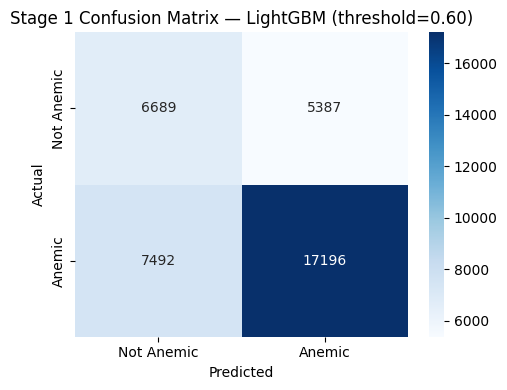

In [ ]:
# Lock in threshold 0.60
best_thresh = 0.60
y1_pred_tuned = (y1_prob >= best_thresh).astype(int)

print(f"FINAL Stage 1 Report — {best1_name} "
      f"(threshold = {best_thresh})")
print("=" * 55)
print(classification_report(
    y1_test, y1_pred_tuned,
    target_names=['Not Anemic', 'Anemic']
))

# AUC stays the same regardless of threshold
auc1 = roc_auc_score(y1_test, y1_prob)
print(f"AUC-ROC: {auc1:.4f}")
print(f"Cohen Kappa: {cohen_kappa_score(y1_test, y1_pred_tuned):.4f}")

# Tuned confusion matrix
cm1_tuned = confusion_matrix(y1_test, y1_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Anemic', 'Anemic'],
            yticklabels=['Not Anemic', 'Anemic'])
plt.title(f'Stage 1 Confusion Matrix — {best1_name} '
          f'(threshold=0.60)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('stage1_confusion_matrix_final.png', dpi=150)
plt.show()

SHAP Analysis — Stage 1 (LightGBM)


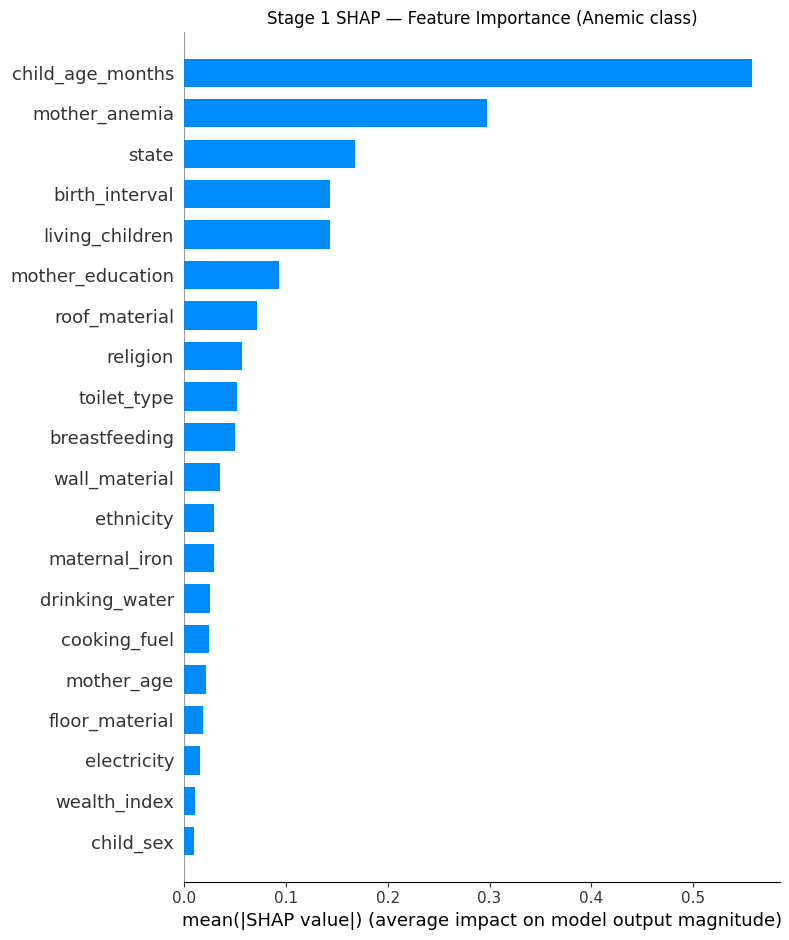

Saved: stage1_shap_bar.png


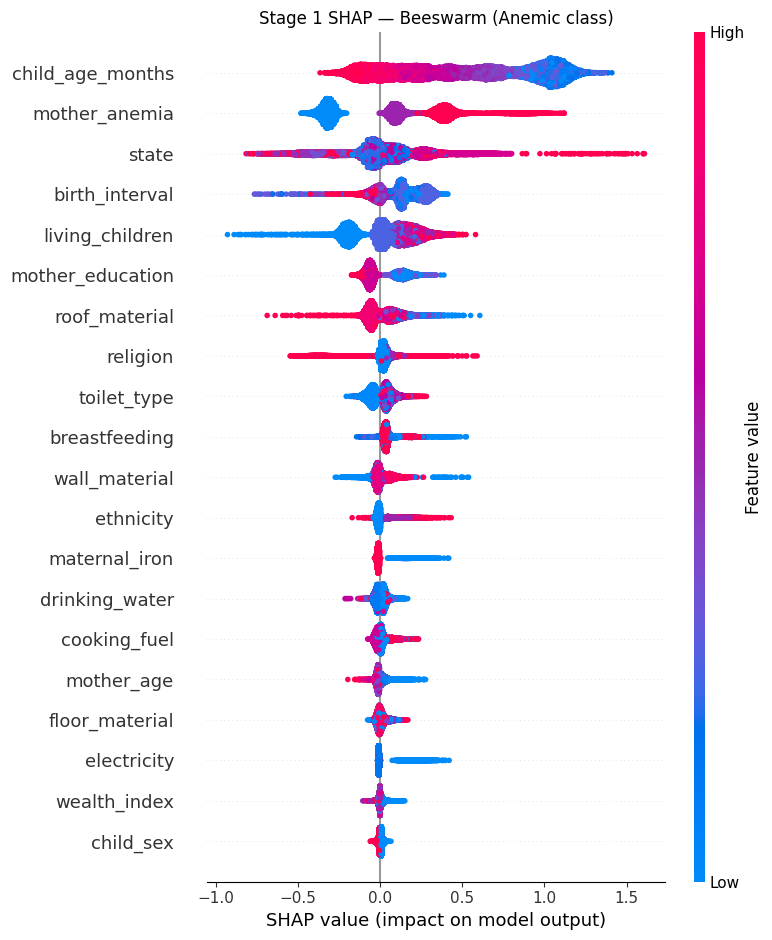

Saved: stage1_shap_beeswarm.png

Top 10 features by SHAP importance (Stage 1):
         feature  mean_shap_value
child_age_months         0.557099
   mother_anemia         0.297070
           state         0.167747
  birth_interval         0.143986
 living_children         0.143127
mother_education         0.093687
   roof_material         0.071509
        religion         0.057423
     toilet_type         0.052090
   breastfeeding         0.049963


In [ ]:
# Stage 1 SHAP — using tuned threshold model
print(f"SHAP Analysis — Stage 1 ({best1_name})")
print("=" * 55)

# Use same test data as final Stage 1 report
if best1_name == 'CatBoost':
    X1_shap = prepare_for_catboost(X1_test, cat_cols)
else:
    X1_shap = X1_test

# Compute SHAP values
explainer1 = shap.TreeExplainer(best1_model)
shap_vals1 = explainer1.shap_values(X1_shap)

# Handle both old and new SHAP output formats
if isinstance(shap_vals1, list):
    sv1 = shap_vals1[1]   # class 1 = Anemic
else:
    sv1 = (shap_vals1[:, :, 1]
           if shap_vals1.ndim == 3
           else shap_vals1)

# ── Plot 1: Bar plot — global feature importance ──────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv1, X1_shap,
    plot_type='bar',
    show=False
)
plt.title('Stage 1 SHAP — Feature Importance (Anemic class)')
plt.tight_layout()
plt.savefig('stage1_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage1_shap_bar.png")

# ── Plot 2: Beeswarm — direction of effect ────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv1, X1_shap,
    show=False
)
plt.title('Stage 1 SHAP — Beeswarm (Anemic class)')
plt.tight_layout()
plt.savefig('stage1_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: stage1_shap_beeswarm.png")

# ── Print top 10 features by mean SHAP value ─────────────────
shap_importance = pd.DataFrame({
    'feature'         : X1_shap.columns,
    'mean_shap_value' : np.abs(sv1).mean(axis=0)
}).sort_values('mean_shap_value',
               ascending=False).reset_index(drop=True)

print("\nTop 10 features by SHAP importance (Stage 1):")
print(shap_importance.head(10).to_string(index=False))

In [ ]:
import os
import json
import pickle
from datetime import datetime
from google.colab import files as colab_files

os.makedirs('/content/stage1_results', exist_ok=True)

print("=" * 55)
print("SAVING ALL STAGE 1 RESULTS")
print("=" * 55)

# ── 1. Model comparison table ─────────────────────
results1.to_csv(
    '/content/stage1_results/'
    'stage1_model_comparison.csv',
    index=False)
print("✓ 1. Model comparison table saved")

# ── 2. Final metrics at threshold 0.60 ───────────
if best1_name == 'CatBoost':
    X1_final_eval = prepare_for_catboost(
        X1_test, cat_cols)
else:
    X1_final_eval = X1_test

y1_prob_final = best1_model.predict_proba(
    X1_final_eval)[:, 1]
y1_pred_final = (
    y1_prob_final >= 0.60).astype(int)

w_total = df['survey_weight'].sum()

stage1_final_metrics = {
    # Model info
    'best_model'            : best1_name,
    'threshold'             : 0.60,

    # Performance metrics
    'accuracy'              : round(accuracy_score(
                                  y1_test,
                                  y1_pred_final), 4),
    'precision_macro'       : round(precision_score(
                                  y1_test,
                                  y1_pred_final,
                                  average='macro',
                                  zero_division=0), 4),
    'recall_macro'          : round(recall_score(
                                  y1_test,
                                  y1_pred_final,
                                  average='macro',
                                  zero_division=0), 4),
    'f1_macro'              : round(f1_score(
                                  y1_test,
                                  y1_pred_final,
                                  average='macro',
                                  zero_division=0), 4),
    'f1_weighted'           : round(f1_score(
                                  y1_test,
                                  y1_pred_final,
                                  average='weighted',
                                  zero_division=0), 4),
    'f1_anemic'             : round(f1_score(
                                  y1_test,
                                  y1_pred_final,
                                  pos_label=1,
                                  zero_division=0), 4),
    'f1_not_anemic'         : round(f1_score(
                                  y1_test,
                                  y1_pred_final,
                                  pos_label=0,
                                  zero_division=0), 4),
    'auc_roc'               : round(roc_auc_score(
                                  y1_test,
                                  y1_prob_final), 4),
    'cohen_kappa'           : round(cohen_kappa_score(
                                  y1_test,
                                  y1_pred_final), 4),

    # Dataset counts
    'total_records'         : len(df),
    'not_anemic_count'      : int(
        (df['anemia_level']==0).sum()),
    'mild_count'            : int(
        (df['anemia_level']==1).sum()),
    'moderate_count'        : int(
        (df['anemia_level']==2).sum()),
    'severe_count'          : int(
        (df['anemia_level']==3).sum()),
    'anemic_count'          : int(
        (df['anemia_level']>0).sum()),
    'train_size'            : len(X1_train),
    'test_size'             : len(X1_test),
    'anemic_test'           : int(
        (y1_test==1).sum()),
    'not_anemic_test'       : int(
        (y1_test==0).sum()),

    # Unweighted percentages (reference only)
    'uw_not_anemic_pct'     : round(
        (df['anemia_level']==0).mean()*100, 2),
    'uw_mild_pct'           : round(
        (df['anemia_level']==1).mean()*100, 2),
    'uw_moderate_pct'       : round(
        (df['anemia_level']==2).mean()*100, 2),
    'uw_severe_pct'         : round(
        (df['anemia_level']==3).mean()*100, 2),
    'uw_anemia_prevalence'  : round(
        (df['anemia_level']>0).mean()*100, 2),

    # Weighted percentages (use in paper)
    'w_not_anemic_pct'      : round(
        df.loc[df['anemia_level']==0,
               'survey_weight'].sum()
        / w_total * 100, 2),
    'w_mild_pct'            : round(
        df.loc[df['anemia_level']==1,
               'survey_weight'].sum()
        / w_total * 100, 2),
    'w_moderate_pct'        : round(
        df.loc[df['anemia_level']==2,
               'survey_weight'].sum()
        / w_total * 100, 2),
    'w_severe_pct'          : round(
        df.loc[df['anemia_level']==3,
               'survey_weight'].sum()
        / w_total * 100, 2),
    'w_anemia_prevalence'   : round(
        df.loc[df['anemia_level']>0,
               'survey_weight'].sum()
        / w_total * 100, 2),

    # Dataset info
    'dataset'               : 'NFHS-5 KR file',
    'survey_file'           : 'IAKR7EDT.DTA',
    'survey_period'         : '2019-21',
    'country'               : 'India',
    'age_group'             : '6-59 months',
    'weight_variable'       : 'v005/1000000',
    'anemia_variable'       : 'hw57',
    'who_threshold'         : (
        'Hb <11 g/dL for children 6-59 months'),
    'who_reference'         : (
        'WHO/NMH/NHD/MNM/11.1 (2011)'),
    'timestamp'             : datetime.now(
        ).strftime('%Y-%m-%d %H:%M'),
}

with open(
        '/content/stage1_results/'
        'stage1_final_metrics.json', 'w') as f:
    json.dump(stage1_final_metrics, f, indent=2)

print("✓ 2. Final metrics saved")
print("\nKey metrics:")
print(f"  Total records    : "
      f"{stage1_final_metrics['total_records']:,}")
print(f"  Best model       : "
      f"{stage1_final_metrics['best_model']}")
print(f"  Threshold        : "
      f"{stage1_final_metrics['threshold']}")
print(f"  AUC-ROC          : "
      f"{stage1_final_metrics['auc_roc']}")
print(f"  F1 Macro         : "
      f"{stage1_final_metrics['f1_macro']}")
print(f"  Cohen Kappa      : "
      f"{stage1_final_metrics['cohen_kappa']}")
print(f"\nWeighted prevalence figures:")
print(f"  Anemia prev (W)  : "
      f"{stage1_final_metrics['w_anemia_prevalence']}%")
print(f"  Not anemic (W)   : "
      f"{stage1_final_metrics['w_not_anemic_pct']}%")
print(f"  Mild (W)         : "
      f"{stage1_final_metrics['w_mild_pct']}%")
print(f"  Moderate (W)     : "
      f"{stage1_final_metrics['w_moderate_pct']}%")
print(f"  Severe (W)       : "
      f"{stage1_final_metrics['w_severe_pct']}%")

# ── 3. Per-class classification report ───────────
report = classification_report(
    y1_test, y1_pred_final,
    target_names=['Not Anemic', 'Anemic'],
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    '/content/stage1_results/'
    'stage1_classification_report.csv')
print("\n✓ 3. Classification report saved")
print(classification_report(
    y1_test, y1_pred_final,
    target_names=['Not Anemic', 'Anemic']
))

# ── 4. Confusion matrix ───────────────────────────
cm1 = confusion_matrix(y1_test, y1_pred_final)
cm1_df = pd.DataFrame(
    cm1,
    index=['Actual Not Anemic',
           'Actual Anemic'],
    columns=['Pred Not Anemic',
             'Pred Anemic']
)
cm1_df.to_csv(
    '/content/stage1_results/'
    'stage1_confusion_matrix.csv')
print("✓ 4. Confusion matrix saved")
print(cm1_df)

# ── 5. SHAP importance ────────────────────────────
shap_importance1 = pd.DataFrame({
    'feature'        : X1_final_eval.columns,
    'mean_shap_value': np.abs(sv1).mean(axis=0)
}).sort_values(
    'mean_shap_value',
    ascending=False
).reset_index(drop=True)
shap_importance1['rank'] = range(
    1, len(shap_importance1)+1)

shap_importance1.to_csv(
    '/content/stage1_results/'
    'stage1_shap_importance.csv',
    index=False)
print("\n✓ 5. SHAP importance saved")
print("\nTop 10 SHAP features:")
print(shap_importance1.head(10).to_string(
    index=False))

# ── 6. Threshold tuning results ───────────────────
thresh_df.to_csv(
    '/content/stage1_results/'
    'stage1_threshold_tuning.csv',
    index=False)
print("\n✓ 6. Threshold tuning saved")

# ── 7. Best model pickle ──────────────────────────
with open(
        '/content/stage1_results/'
        'best_model_stage1.pkl', 'wb') as f:
    pickle.dump(best1_model, f)
print("✓ 7. Best model saved")

# ── 8. Feature list ───────────────────────────────
pd.DataFrame({
    'feature': feature_cols,
    'type'   : ['categorical'
                if c in cat_cols
                else 'continuous'
                for c in feature_cols]
}).to_csv(
    '/content/stage1_results/'
    'stage1_features.csv',
    index=False)
print("✓ 8. Feature list saved")

# ── 9. Weighted state prevalence ──────────────────
state_anemia_w = []
for state_code in sorted(df['state'].unique()):
    sd = df[df['state']==state_code].copy()
    wt = sd['survey_weight'].sum()
    wa = sd.loc[
        sd['anemia_level']>0,
        'survey_weight'].sum()
    state_anemia_w.append({
        'state'      : state_code,
        'n_sample'   : len(sd),
        'prevalence' : round(
            wa/wt*100, 1) if wt > 0 else np.nan,
    })

state_anemia_w = pd.DataFrame(state_anemia_w)

state_name_map = {
    1:'Jammu & Kashmir',
    2:'Himachal Pradesh',
    3:'Punjab', 4:'Chandigarh',
    5:'Uttarakhand', 6:'Haryana',
    7:'NCT of Delhi', 8:'Rajasthan',
    9:'Uttar Pradesh', 10:'Bihar',
    11:'Sikkim', 12:'Arunachal Pradesh',
    13:'Nagaland', 14:'Manipur',
    15:'Mizoram', 16:'Tripura',
    17:'Meghalaya', 18:'Assam',
    19:'West Bengal', 20:'Jharkhand',
    21:'Odisha', 22:'Chhattisgarh',
    23:'Madhya Pradesh', 24:'Gujarat',
    25:'Dadra & NH and D&D',
    27:'Maharashtra', 28:'Andhra Pradesh',
    29:'Karnataka', 30:'Goa',
    31:'Lakshadweep', 32:'Kerala',
    33:'Tamil Nadu', 34:'Puducherry',
    35:'Andaman & Nicobar',
    36:'Telangana', 37:'Ladakh',
}
state_anemia_w['state_name'] = \
    state_anemia_w['state'].astype(int).map(
    state_name_map)

state_anemia_w.to_csv(
    '/content/stage1_results/'
    'stage1_state_prevalence_weighted.csv',
    index=False)
print("✓ 9. Weighted state prevalence saved")

# ── 10. Summary for paper ─────────────────────────
print("\n" + "=" * 55)
print("STAGE 1 SUMMARY FOR PAPER")
print("=" * 55)
print(f"\nDataset  : NFHS-5 KR, India 2019-21")
print(f"Records  : "
      f"{stage1_final_metrics['total_records']:,}")
print(f"Features : {len(feature_cols)} "
      f"({len(cat_cols)} categorical, "
      f"{len(cont_cols)} continuous)")
print(f"\nClass distribution (use weighted in paper):")
print(f"  Not anemic : "
      f"{stage1_final_metrics['not_anemic_count']:,} "
      f"(W: {stage1_final_metrics['w_not_anemic_pct']}%)")
print(f"  Mild       : "
      f"{stage1_final_metrics['mild_count']:,} "
      f"(W: {stage1_final_metrics['w_mild_pct']}%)")
print(f"  Moderate   : "
      f"{stage1_final_metrics['moderate_count']:,} "
      f"(W: {stage1_final_metrics['w_moderate_pct']}%)")
print(f"  Severe     : "
      f"{stage1_final_metrics['severe_count']:,} "
      f"(W: {stage1_final_metrics['w_severe_pct']}%)")
print(f"\nAnemia prevalence:")
print(f"  Weighted   : "
      f"{stage1_final_metrics['w_anemia_prevalence']}%")
print(f"  Unweighted : "
      f"{stage1_final_metrics['uw_anemia_prevalence']}%")
print(f"\nBest model : {best1_name}")
print(f"Threshold  : 0.60")
print(f"AUC-ROC    : "
      f"{stage1_final_metrics['auc_roc']}")
print(f"F1 Macro   : "
      f"{stage1_final_metrics['f1_macro']}")
print(f"F1 Anemic  : "
      f"{stage1_final_metrics['f1_anemic']}")
print(f"F1 Not An  : "
      f"{stage1_final_metrics['f1_not_anemic']}")
print(f"Kappa      : "
      f"{stage1_final_metrics['cohen_kappa']}")
print(f"\nTop 5 SHAP predictors:")
for _, row in shap_importance1.head(5).iterrows():
    print(f"  {int(row['rank'])}. "
          f"{row['feature']:<22} "
          f"SHAP={row['mean_shap_value']:.4f}")

# ── 11. Zip and download ──────────────────────────
import shutil
print("\n── Zipping all files ──")
shutil.make_archive(
    '/content/STAGE1_COMPLETE',
    'zip',
    '/content/stage1_results'
)
size = os.path.getsize(
    '/content/STAGE1_COMPLETE.zip') / 1e6
print(f"STAGE1_COMPLETE.zip ({size:.1f} MB)")

print("\nFile inventory:")
for fname in sorted(
        os.listdir('/content/stage1_results')):
    fpath = (f'/content/stage1_results/'
             f'{fname}')
    fsize = os.path.getsize(fpath)
    print(f"  {fname:<45} "
          f"{fsize:>8} bytes")

colab_files.download(
    '/content/STAGE1_COMPLETE.zip')
print("\n✓ Download started")

SAVING ALL STAGE 1 RESULTS
✓ 1. Model comparison table saved
✓ 2. Final metrics saved

Key metrics:
  Total records    : 183,816
  Best model       : LightGBM
  Threshold        : 0.6
  AUC-ROC          : 0.6785
  F1 Macro         : 0.6185
  Cohen Kappa      : 0.2398

Weighted prevalence figures:
  Anemia prev (W)  : 68.03%
  Not anemic (W)   : 31.97%
  Mild (W)         : 29.22%
  Moderate (W)     : 36.69%
  Severe (W)       : 2.12%

✓ 3. Classification report saved
              precision    recall  f1-score   support

  Not Anemic       0.47      0.55      0.51     12076
      Anemic       0.76      0.70      0.73     24688

    accuracy                           0.65     36764
   macro avg       0.62      0.63      0.62     36764
weighted avg       0.67      0.65      0.66     36764

✓ 4. Confusion matrix saved
                   Pred Not Anemic  Pred Anemic
Actual Not Anemic             6689         5387
Actual Anemic                 7492        17196

✓ 5. SHAP importance saved

T

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download started


In [ ]:
# Zip and download all Stage 1 results
import shutil

shutil.make_archive('/content/stage1_results_backup',
                    'zip',
                    '/content/stage1_results')

from google.colab import files
files.download('/content/stage1_results_backup.zip')
print("Download started.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


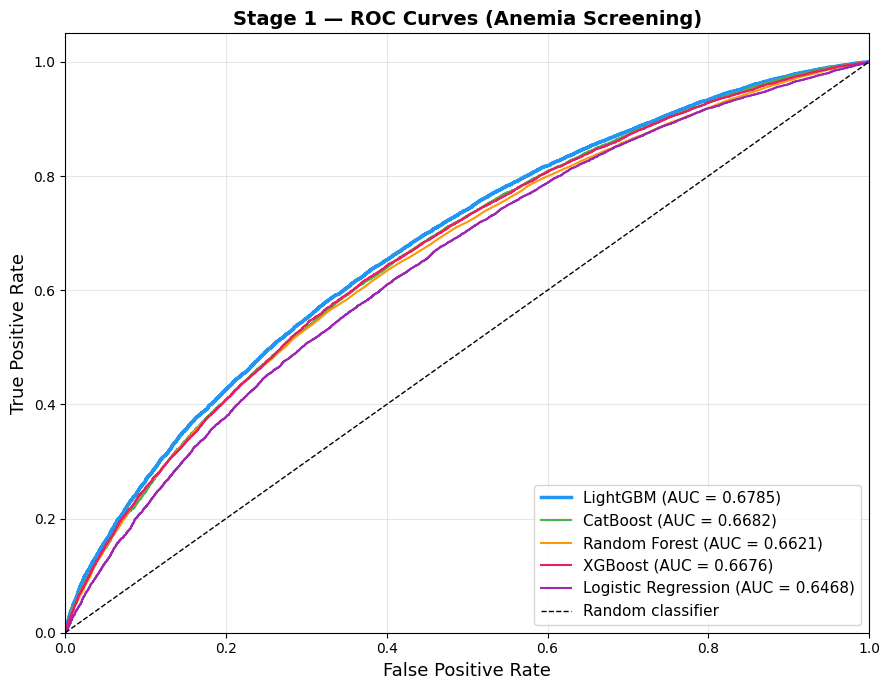

✓ ROC curves saved


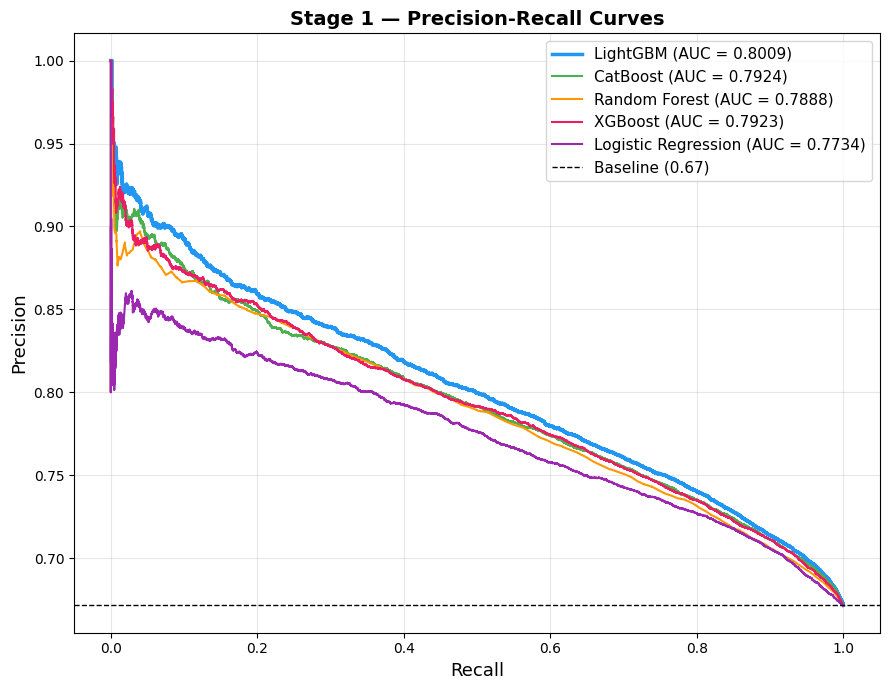

✓ Precision-Recall curves saved


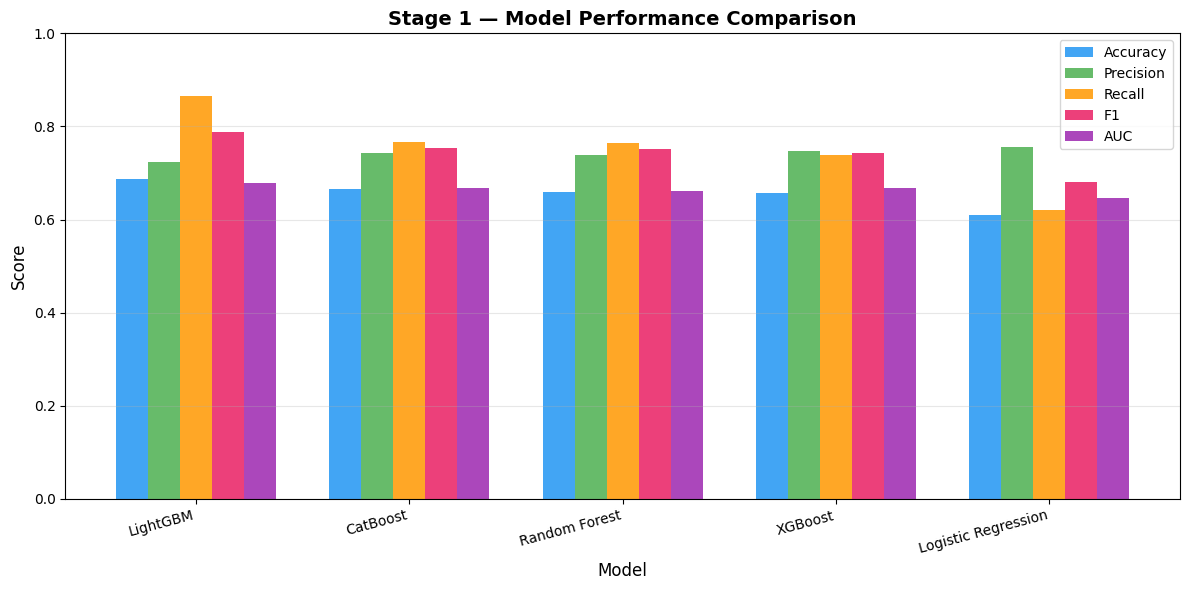

✓ Model comparison chart saved


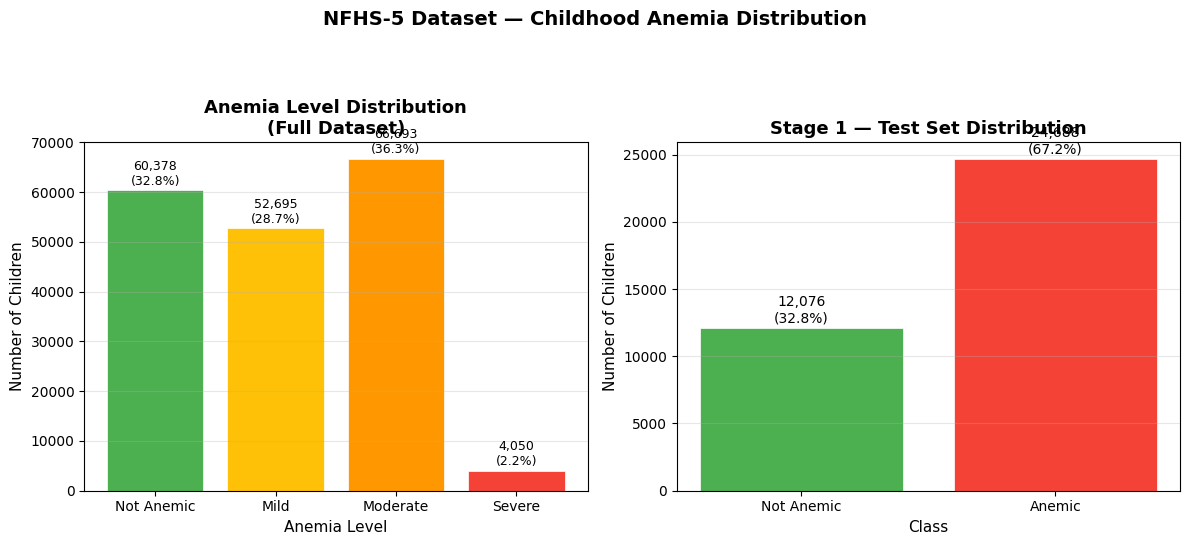

✓ Class distribution chart saved


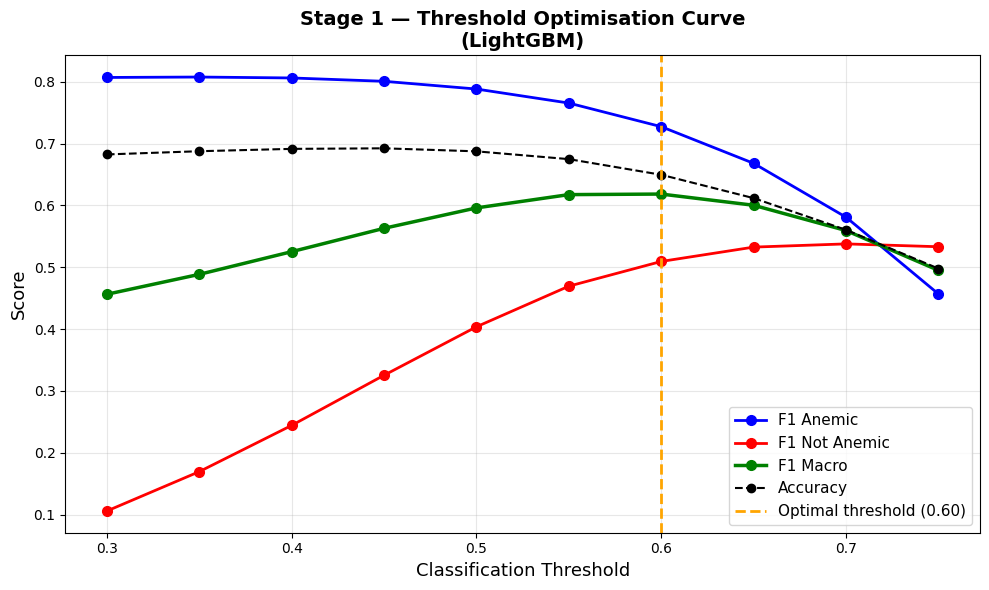

✓ Threshold tuning curve saved


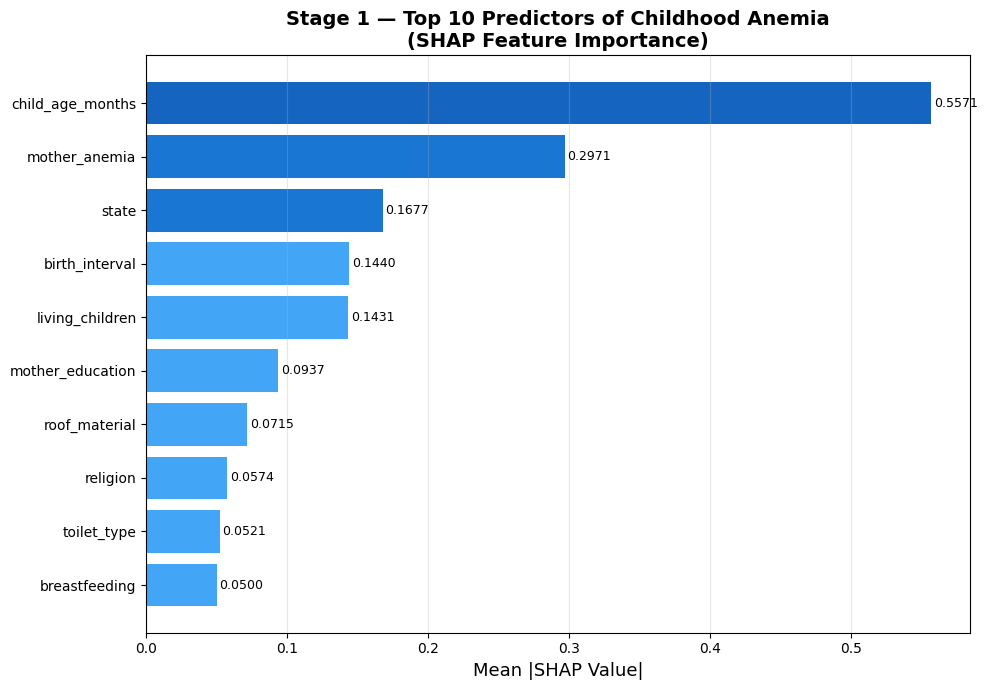

✓ SHAP importance chart saved


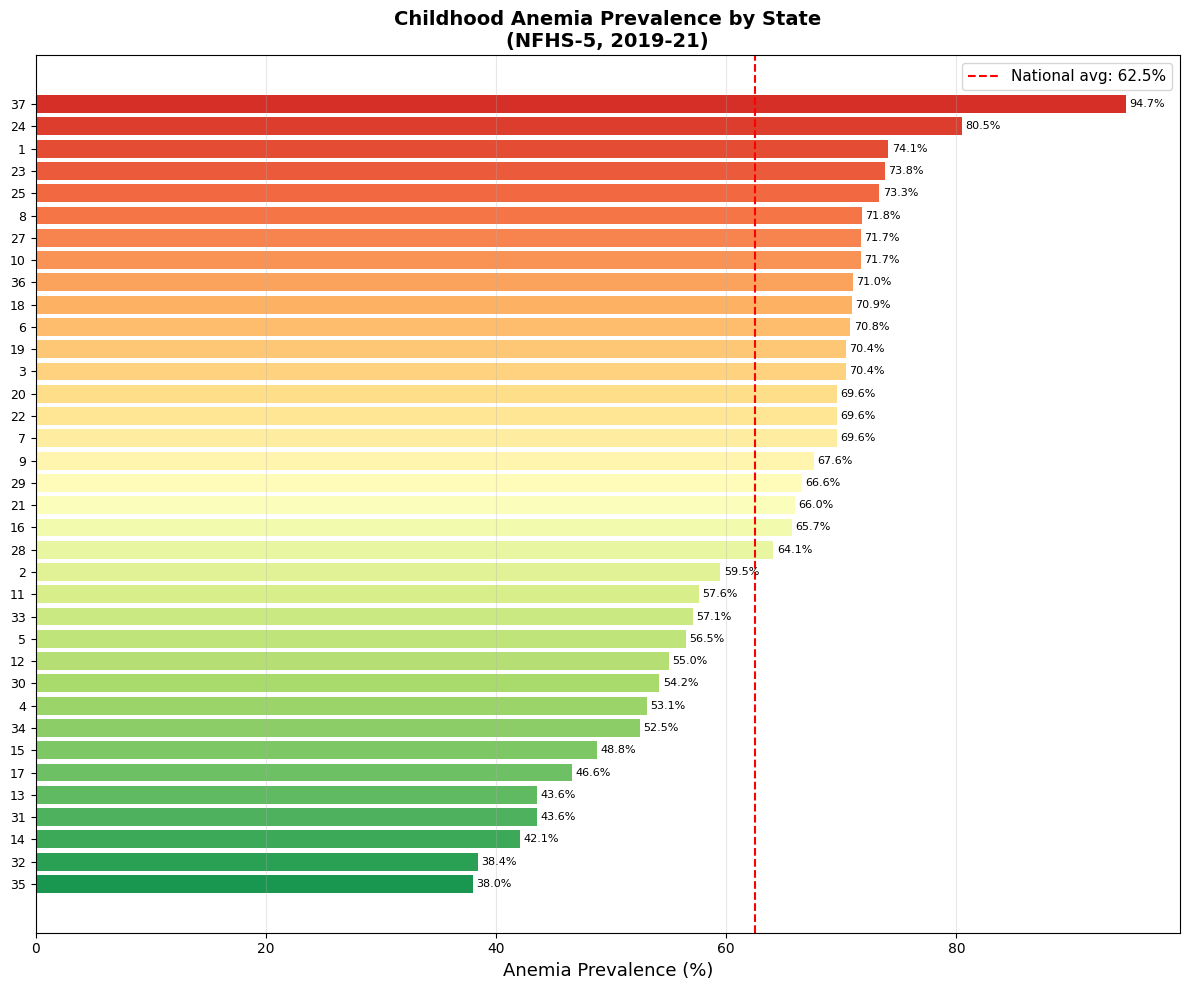

✓ State-level prevalence chart saved

ALL STAGE 1 FIGURES SAVED
  fig_class_distribution.png                      218544 bytes
  fig_model_comparison.png                        162454 bytes
  fig_precision_recall.png                        324800 bytes
  fig_roc_curves.png                              346318 bytes
  fig_shap_importance.png                         179044 bytes
  fig_state_prevalence.png                        292831 bytes
  fig_threshold_tuning.png                        241710 bytes


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
import os

os.makedirs('/content/stage1_results/figures', exist_ok=True)

# ── Figure 1: ROC Curve — all models ─────────────────────────
plt.figure(figsize=(9, 7))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
model_order = ['LightGBM', 'CatBoost', 'Random Forest',
               'XGBoost', 'Logistic Regression']

for color, name in zip(colors, model_order):
    model = trained1[name]
    if name == 'CatBoost':
        X_eval = prepare_for_catboost(X1_test, cat_cols)
    else:
        X_eval = X1_test
    prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y1_test, prob)
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if name == 'LightGBM' else 1.5
    plt.plot(fpr, tpr, color=color, lw=lw,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('Stage 1 — ROC Curves (Anemia Screening)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/stage1_results/figures/fig_roc_curves.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ ROC curves saved")

# ── Figure 2: Precision-Recall Curve ─────────────────────────
plt.figure(figsize=(9, 7))

for color, name in zip(colors, model_order):
    model = trained1[name]
    if name == 'CatBoost':
        X_eval = prepare_for_catboost(X1_test, cat_cols)
    else:
        X_eval = X1_test
    prob = model.predict_proba(X_eval)[:, 1]
    precision, recall, _ = precision_recall_curve(
        y1_test, prob)
    pr_auc = auc(recall, precision)
    lw = 2.5 if name == 'LightGBM' else 1.5
    plt.plot(recall, precision, color=color, lw=lw,
             label=f'{name} (AUC = {pr_auc:.4f})')

# Baseline — random classifier
baseline = y1_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--',
            lw=1, label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Stage 1 — Precision-Recall Curves',
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_precision_recall.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Precision-Recall curves saved")

# ── Figure 3: Model comparison bar chart ─────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall',
                   'F1', 'AUC']
results1_plot = results1[
    ['Model'] + metrics_to_plot].set_index('Model')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results1_plot))
width = 0.15
bars_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for i, metric in enumerate(metrics_to_plot):
    vals = results1_plot[metric].values
    bars = ax.bar(x + i*width, vals, width,
                  label=metric, color=bars_colors[i],
                  alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Stage 1 — Model Performance Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results1_plot.index,
                   rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_model_comparison.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Model comparison chart saved")

# ── Figure 4: Class distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — full dataset 4-class
labels4 = ['Not Anemic', 'Mild', 'Moderate', 'Severe']
counts4  = [int((df['anemia_level']==i).sum())
            for i in range(4)]
colors4  = ['#4CAF50','#FFC107','#FF9800','#F44336']
bars = axes[0].bar(labels4, counts4, color=colors4,
                   edgecolor='white', linewidth=0.5)
axes[0].set_title('Anemia Level Distribution\n(Full Dataset)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Children', fontsize=11)
axes[0].set_xlabel('Anemia Level', fontsize=11)
for bar, count in zip(bars, counts4):
    pct = count / sum(counts4) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

# Right — Stage 1 binary split
labels2 = ['Not Anemic', 'Anemic']
counts2  = [int((y1_test==0).sum()),
            int((y1_test==1).sum())]
colors2  = ['#4CAF50', '#F44336']
bars2 = axes[1].bar(labels2, counts2, color=colors2,
                    edgecolor='white', linewidth=0.5)
axes[1].set_title('Stage 1 — Test Set Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Children', fontsize=11)
axes[1].set_xlabel('Class', fontsize=11)
for bar, count in zip(bars2, counts2):
    pct = count / sum(counts2) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('NFHS-5 Dataset — Childhood Anemia Distribution',
             fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_class_distribution.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Class distribution chart saved")

# ── Figure 5: Threshold tuning curve ─────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['threshold'], thresh_df['f1_anemic'],
         'b-o', label='F1 Anemic', linewidth=2, markersize=7)
plt.plot(thresh_df['threshold'], thresh_df['f1_not_anemic'],
         'r-o', label='F1 Not Anemic', linewidth=2, markersize=7)
plt.plot(thresh_df['threshold'], thresh_df['f1_macro'],
         'g-o', label='F1 Macro', linewidth=2.5, markersize=7)
plt.plot(thresh_df['threshold'], thresh_df['accuracy'],
         'k--o', label='Accuracy', linewidth=1.5, markersize=6)
plt.axvline(x=0.60, color='orange', linestyle='--',
            linewidth=2, label='Optimal threshold (0.60)')
plt.xlabel('Classification Threshold', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.title('Stage 1 — Threshold Optimisation Curve\n(LightGBM)',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_threshold_tuning.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Threshold tuning curve saved")

# ── Figure 6: SHAP top 10 bar chart ──────────────────────────
plt.figure(figsize=(10, 7))
top10 = shap_importance1.head(10)
colors_shap = ['#1565C0' if i == 0 else
               '#1976D2' if i < 3 else
               '#42A5F5'
               for i in range(len(top10))]
bars = plt.barh(top10['feature'][::-1],
                top10['mean_shap_value'][::-1],
                color=colors_shap[::-1])
plt.xlabel('Mean |SHAP Value|', fontsize=13)
plt.title('Stage 1 — Top 10 Predictors of Childhood Anemia\n'
          '(SHAP Feature Importance)',
          fontsize=14, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars,
                    top10['mean_shap_value'][::-1]):
    plt.text(bar.get_width() + 0.002, bar.get_y() +
             bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_shap_importance.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP importance chart saved")

# ── Figure 7: State-level anemia heatmap ─────────────────────
# Anemia prevalence by state from NFHS-5
state_anemia = df.groupby('state').agg(
    total=('anemia_level', 'count'),
    anemic=('anemia_level', lambda x: (x > 0).sum())
).reset_index()
state_anemia['prevalence'] = (
    state_anemia['anemic'] /
    state_anemia['total'] * 100).round(1)
state_anemia = state_anemia.sort_values(
    'prevalence', ascending=True)

plt.figure(figsize=(12, 10))
colors_state = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(state_anemia)))
bars = plt.barh(range(len(state_anemia)),
                state_anemia['prevalence'],
                color=colors_state)
plt.yticks(range(len(state_anemia)),
           state_anemia['state'].astype(int),
           fontsize=9)
plt.xlabel('Anemia Prevalence (%)', fontsize=13)
plt.title('Childhood Anemia Prevalence by State\n'
          '(NFHS-5, 2019-21)',
          fontsize=14, fontweight='bold')
for bar, (_, row) in zip(bars, state_anemia.iterrows()):
    plt.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{row['prevalence']}%",
             va='center', fontsize=8)
plt.axvline(x=state_anemia['prevalence'].mean(),
            color='red', linestyle='--', linewidth=1.5,
            label=f"National avg: "
                  f"{state_anemia['prevalence'].mean():.1f}%")
plt.legend(fontsize=11)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_state_prevalence.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ State-level prevalence chart saved")

# ── Summary of all figures ────────────────────────────────────
print("\n" + "=" * 55)
print("ALL STAGE 1 FIGURES SAVED")
print("=" * 55)
figures = os.listdir(
    '/content/stage1_results/figures')
for f in sorted(figures):
    size = os.path.getsize(
        f'/content/stage1_results/figures/{f}')
    print(f"  {f:<45} {size:>8} bytes")

Stage 2

In [ ]:
filename = list(uploaded.keys())[0]
print(f"\nFile uploaded: {filename}")
print(f"File size: {len(uploaded[filename])/1e6:.1f} MB")

# Verify it is the right file
if not filename.upper().endswith('.DTA'):
    print("ERROR: Wrong file type.")
    print("You need IAKR7EDT.DTA not", filename)
else:
    print("Correct file type. Loading...")
    df_raw = pd.read_stata(
        io.BytesIO(uploaded[filename]),
        convert_categoricals=False
    )
    print(f"Success! Shape: {df_raw.shape}")


File uploaded: IAKR7EFL (1).DTA
File size: 441.4 MB
Correct file type. Loading...
Success! Shape: (232920, 1644)


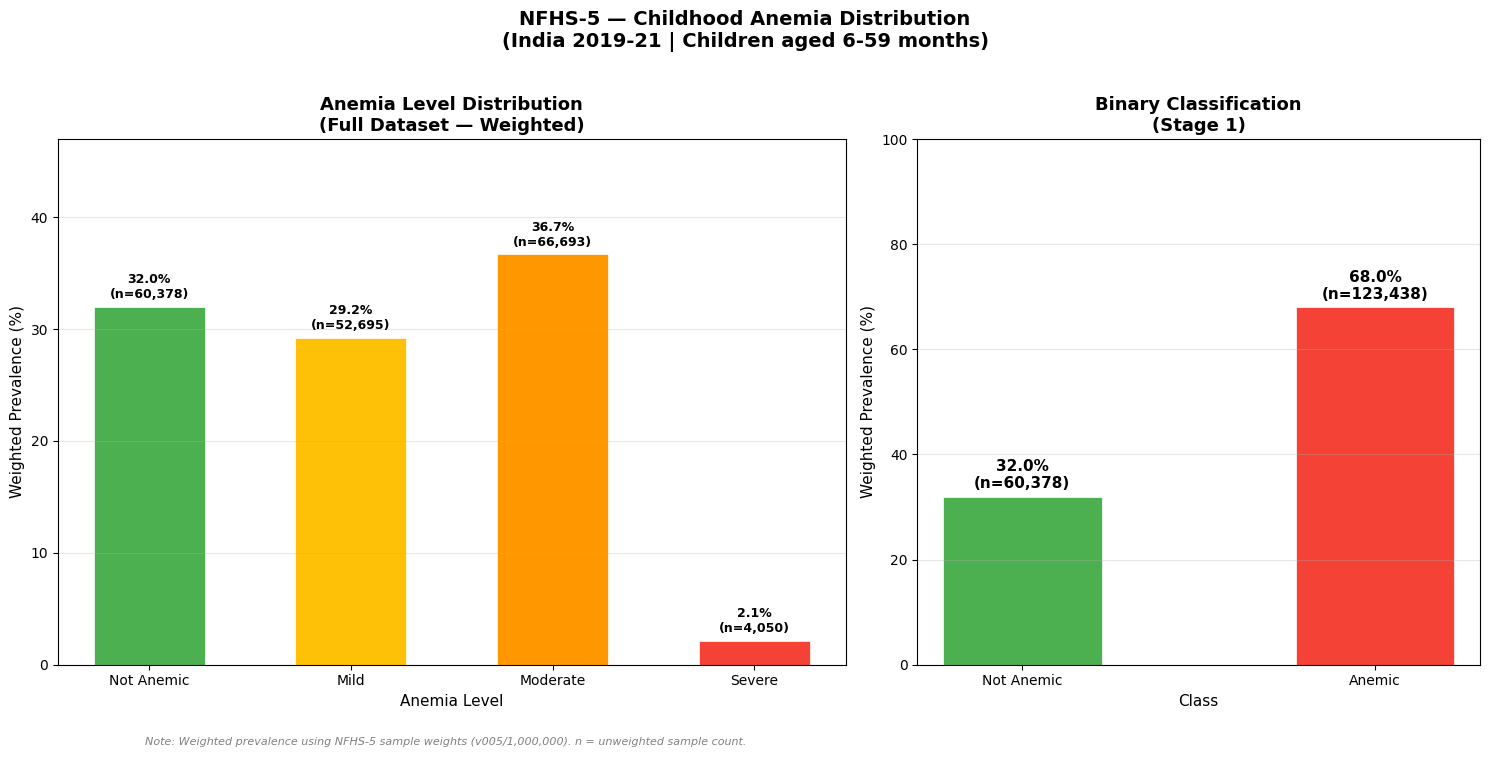

✓ Class distribution chart saved (weighted)


In [ ]:
# ── Figure 4: Class distribution (weighted) ──────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(15, 7),
    gridspec_kw={'width_ratios': [1.4, 1]})

# Weighted counts
w_total  = df['survey_weight'].sum()
labels4  = ['Not Anemic', 'Mild',
            'Moderate', 'Severe']
colors4  = ['#4CAF50', '#FFC107',
            '#FF9800', '#F44336']
w_pcts4  = [
    df.loc[df['anemia_level']==i,
           'survey_weight'].sum()
    / w_total * 100
    for i in [0, 1, 2, 3]]
n_vals4  = [
    int((df['anemia_level']==i).sum())
    for i in [0, 1, 2, 3]]
w_anemic_pct = sum(w_pcts4[1:])

# Left — 4 class weighted
bars1 = axes[0].bar(
    labels4, w_pcts4,
    color=colors4,
    edgecolor='white',
    linewidth=0.5, width=0.55)
axes[0].set_title(
    'Anemia Level Distribution\n'
    '(Full Dataset — Weighted)',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel(
    'Weighted Prevalence (%)', fontsize=11)
axes[0].set_xlabel(
    'Anemia Level', fontsize=11)
axes[0].set_ylim(0, max(w_pcts4)*1.28)
axes[0].grid(True, axis='y', alpha=0.3)
for bar, pct, nv in zip(
        bars1, w_pcts4, n_vals4):
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f'{pct:.1f}%\n(n={nv:,})',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')


# Right — binary weighted
labels2  = ['Not Anemic', 'Anemic']
colors2  = ['#4CAF50', '#F44336']
w_pcts2  = [w_pcts4[0], w_anemic_pct]
n_vals2  = [n_vals4[0], sum(n_vals4[1:])]

bars2 = axes[1].bar(
    labels2, w_pcts2,
    color=colors2,
    edgecolor='white',
    linewidth=0.5, width=0.45)
axes[1].set_title(
    'Binary Classification\n'
    '(Stage 1)',
    fontsize=13, fontweight='bold')
axes[1].set_ylabel(
    'Weighted Prevalence (%)', fontsize=11)
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylim(0, 100)
axes[1].grid(True, axis='y', alpha=0.3)
for bar, pct, nv in zip(
        bars2, w_pcts2, n_vals2):
    axes[1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f'{pct:.1f}%\n(n={nv:,})',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold')


plt.suptitle(
    'NFHS-5 — Childhood Anemia Distribution\n'
    '(India 2019-21 | '
    'Children aged 6-59 months)',
    fontsize=14, fontweight='bold', y=1.02)
fig.text(
    0.1, -0.03,
    'Note: Weighted prevalence using NFHS-5 '
    'sample weights (v005/1,000,000). '
    'n = unweighted sample count.',
    fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/'
    'fig_class_distribution.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ Class distribution chart saved "
      "(weighted)")

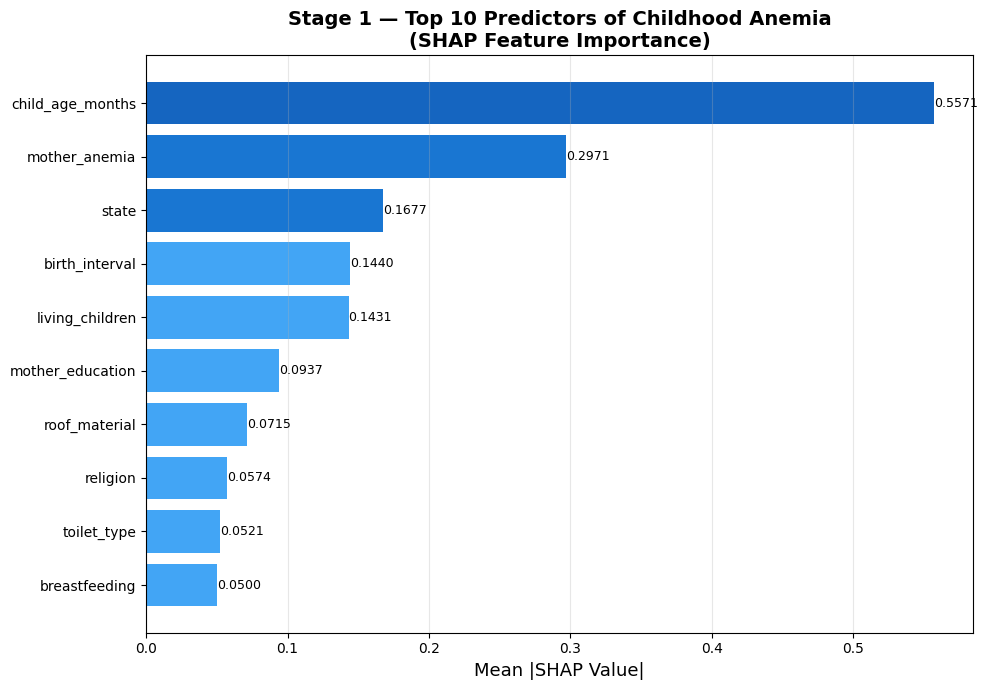

✓ SHAP importance chart saved


In [ ]:
# ── Figure 6: SHAP top 10 bar chart ──────────────────────────
plt.figure(figsize=(10, 7))
top10 = shap_importance1.head(10)
colors_shap = ['#1565C0' if i == 0 else
               '#1976D2' if i < 3 else
               '#42A5F5'
               for i in range(len(top10))]
bars = plt.barh(top10['feature'][::-1],
                top10['mean_shap_value'][::-1],
                color=colors_shap[::-1])
plt.xlabel('Mean |SHAP Value|', fontsize=13)
plt.title('Stage 1 — Top 10 Predictors of Childhood Anemia\n'
          '(SHAP Feature Importance)',
          fontsize=14, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars,
                    top10['mean_shap_value'][::-1]):
    plt.text(bar.get_width() + 0.00001, bar.get_y() +
             bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/fig_shap_importance.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ SHAP importance chart saved")


Downloaded.
India states in shapefile: 36
Matched: 36 | Unmatched: 0


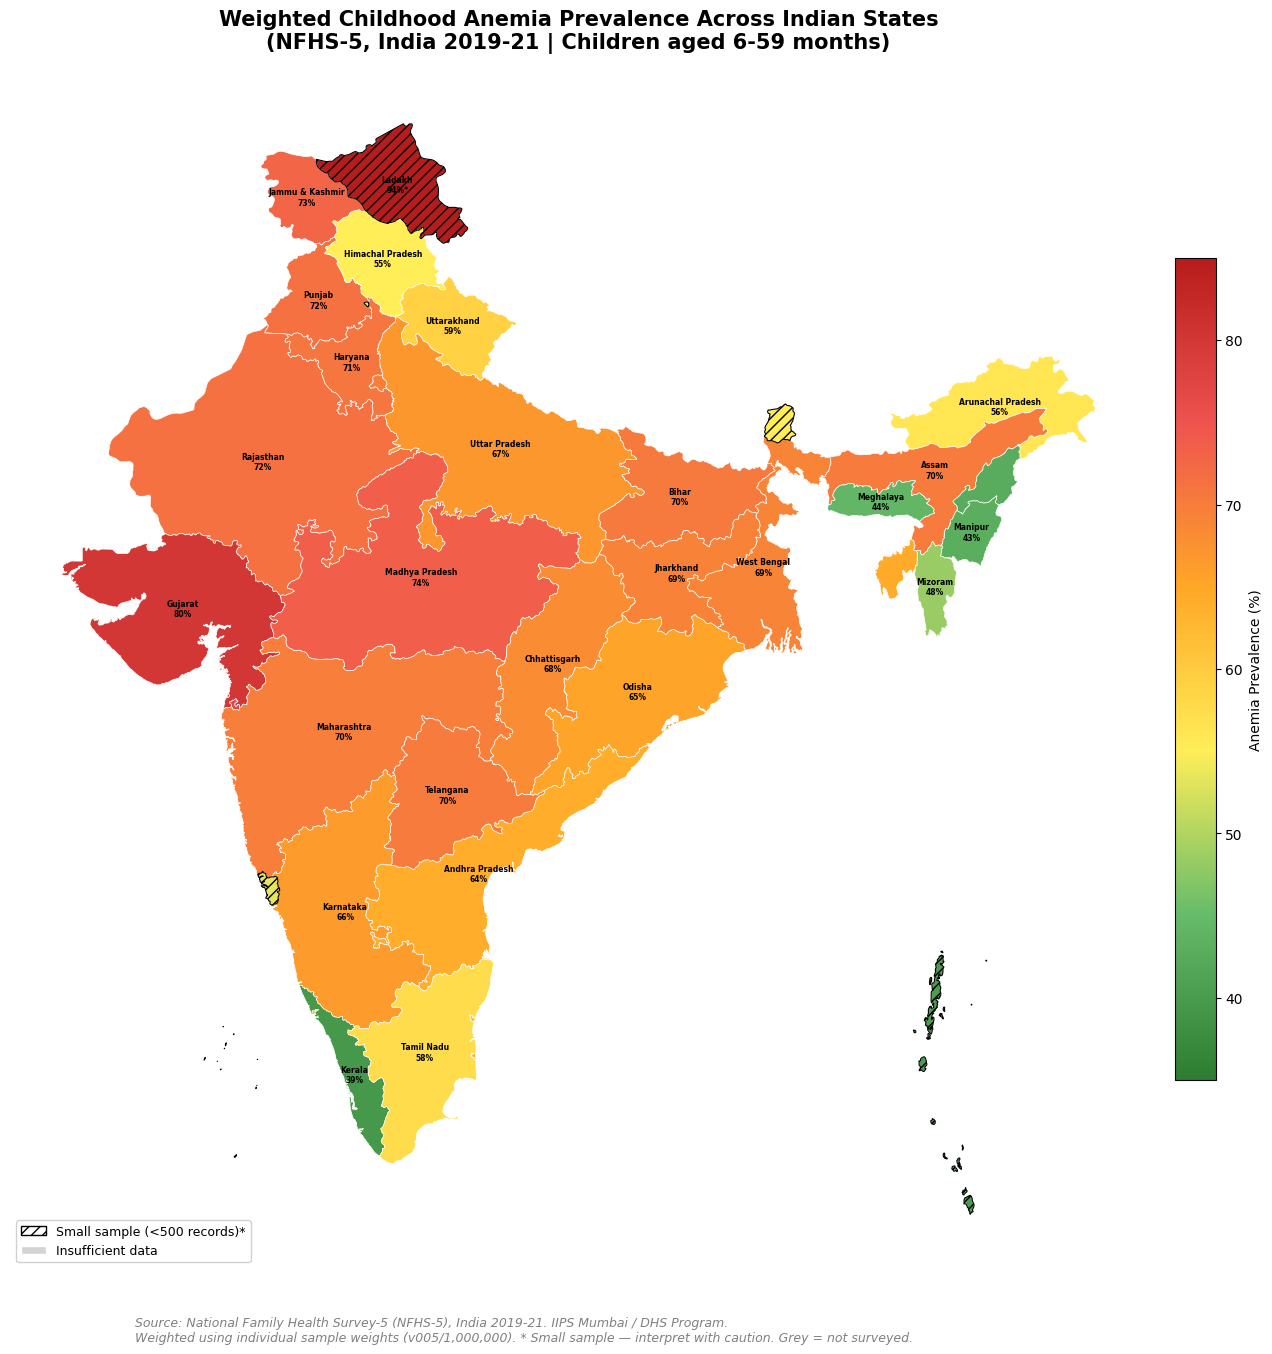

✓ F10: India choropleth map saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


In [ ]:
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import urllib.request
import zipfile
import os

# ── Download shapefile if not present ────────────
if not os.path.exists(
        '/content/ne_shapefile/'
        'ne_10m_admin_1_states_provinces.shp'):
    print("Downloading shapefile...")
    urllib.request.urlretrieve(
        "https://naciscdn.org/naturalearth/10m/"
        "cultural/"
        "ne_10m_admin_1_states_provinces.zip",
        '/content/ne_shapefile.zip')
    with zipfile.ZipFile(
            '/content/ne_shapefile.zip',
            'r') as z:
        z.extractall('/content/ne_shapefile')
    print("Downloaded.")
else:
    print("Shapefile already present.")

# ── Load and filter India ─────────────────────────
world_states = gpd.read_file(
    '/content/ne_shapefile/'
    'ne_10m_admin_1_states_provinces.shp')
india = world_states[
    world_states['admin']=='India'].copy()
print(f"India states in shapefile: {len(india)}")

# ── Name matching ─────────────────────────────────
name_match = {
    'Jammu and Kashmir'   : 'Jammu & Kashmir',
    'Himachal Pradesh'    : 'Himachal Pradesh',
    'Punjab'              : 'Punjab',
    'Chandigarh'          : 'Chandigarh',
    'Uttarakhand'         : 'Uttarakhand',
    'Haryana'             : 'Haryana',
    'NCT of Delhi'        : 'NCT of Delhi',
    'Delhi'               : 'NCT of Delhi',
    'Rajasthan'           : 'Rajasthan',
    'Uttar Pradesh'       : 'Uttar Pradesh',
    'Bihar'               : 'Bihar',
    'Sikkim'              : 'Sikkim',
    'Arunachal Pradesh'   : 'Arunachal Pradesh',
    'Nagaland'            : 'Nagaland',
    'Manipur'             : 'Manipur',
    'Mizoram'             : 'Mizoram',
    'Tripura'             : 'Tripura',
    'Meghalaya'           : 'Meghalaya',
    'Assam'               : 'Assam',
    'West Bengal'         : 'West Bengal',
    'Jharkhand'           : 'Jharkhand',
    'Odisha'              : 'Odisha',
    'Chhattisgarh'        : 'Chhattisgarh',
    'Madhya Pradesh'      : 'Madhya Pradesh',
    'Gujarat'             : 'Gujarat',
    'Maharashtra'         : 'Maharashtra',
    'Andhra Pradesh'      : 'Andhra Pradesh',
    'Karnataka'           : 'Karnataka',
    'Goa'                 : 'Goa',
    'Kerala'              : 'Kerala',
    'Tamil Nadu'          : 'Tamil Nadu',
    'Telangana'           : 'Telangana',
    'Andaman and Nicobar' :
        'Andaman & Nicobar',
    'Andaman and Nicobar Islands':
        'Andaman & Nicobar',
    'Lakshadweep'         : 'Lakshadweep',
    'Puducherry'          : 'Puducherry',
    'Ladakh'              : 'Ladakh',
    'Dadra and Nagar Haveli and Daman and Diu':
        'Dadra & NH and D&D',
}
india['state_name'] = india['name'].map(
    name_match)

# ── Merge with weighted prevalence ────────────────
india_merged = india.merge(
    state_anemia_w[[
        'state_name',
        'prevalence',
        'n_sample']],
    on='state_name',
    how='left')

matched   = india_merged['prevalence'].notna().sum()
unmatched = india_merged['prevalence'].isna().sum()
print(f"Matched: {matched} | "
      f"Unmatched: {unmatched}")

if unmatched > 0:
    print("Unmatched states:")
    print(india_merged[
        india_merged['prevalence'].isna()][
        ['name','state_name']])

# ── Plot choropleth map ───────────────────────────
colors_map = ['#2e7d32', '#66bb6a',
              '#ffee58', '#ffa726',
              '#ef5350', '#b71c1c']
cmap = LinearSegmentedColormap.from_list(
    'anemia', colors_map)

fig, ax = plt.subplots(figsize=(14, 14))

# Main choropleth
india_merged.plot(
    column='prevalence',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label'      :
            'Anemia Prevalence (%)',
        'orientation': 'vertical',
        'shrink'     : 0.6,
        'pad'        : 0.02,
    },
    missing_kwds={
        'color'    : 'lightgrey',
        'edgecolor': 'white',
        'linewidth': 0.5,
        'label'    : 'No data',
    },
    vmin=35, vmax=85,
    ax=ax
)

# Hatch small sample states (<500 records)
small_sample = india_merged[
    india_merged['n_sample'] < 500]
if len(small_sample) > 0:
    small_sample.plot(
        ax=ax,
        color='none',
        edgecolor='black',
        linewidth=0.8,
        hatch='///')

# State name + prevalence labels
for _, row in india_merged.iterrows():
    if pd.notna(row['prevalence']):
        if row['geometry'].area > 1.5:
            centroid = row['geometry'].centroid
            note = '*' \
                if row['n_sample'] < 500 \
                else ''
            ax.annotate(
                f"{row['state_name']}\n"
                f"{row['prevalence']:.0f}%"
                f"{note}",
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=5.5,
                color='black',
                fontweight='bold')

# Legend for hatching
hatch_patch = mpatches.Patch(
    facecolor='white',
    edgecolor='black',
    hatch='///',
    label='Small sample (<500 records)*')
grey_patch = mpatches.Patch(
    facecolor='lightgrey',
    edgecolor='white',
    label='Insufficient data')
ax.legend(
    handles=[hatch_patch, grey_patch],
    loc='lower left',
    fontsize=9,
    framealpha=0.9)

# Title and footnote
ax.set_title(
    'Weighted Childhood Anemia Prevalence '
    'Across Indian States\n'
    '(NFHS-5, India 2019-21 | '
    'Children aged 6-59 months)',
    fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()

fig.text(
    0.1, 0.02,
    'Source: National Family Health Survey-5 '
    '(NFHS-5), India 2019-21. '
    'IIPS Mumbai / DHS Program.\n'
    'Weighted using individual sample weights '
    '(v005/1,000,000). '
    '* Small sample — interpret with caution. '
    'Grey = not surveyed.',
    fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig(
    '/content/stage1_results/figures/'
    'F10_india_anemia_map.png',
    dpi=300, bbox_inches='tight')
plt.show()
print("✓ F10: India choropleth map saved")

# ── Download ──────────────────────────────────────
from google.colab import files
files.download(
    '/content/stage1_results/figures/'
    'F10_india_anemia_map.png')
print("✓ Download started")

In [ ]:
import json
import os
import numpy as np

os.makedirs(
    '/content/stage1_results', exist_ok=True)

# ── Verified counts from current session ─────────
total         = len(df)
not_anemic_n  = int((df['anemia_level']==0).sum())
mild_n        = int((df['anemia_level']==1).sum())
moderate_n    = int((df['anemia_level']==2).sum())
severe_n      = int((df['anemia_level']==3).sum())
anemic_n      = mild_n + moderate_n + severe_n

# Verify counts sum correctly
assert not_anemic_n + mild_n + \
       moderate_n + severe_n == total, \
    "ERROR: Counts do not sum to total!"
print(f"✓ Count verification passed")
print(f"  {not_anemic_n:,} + {mild_n:,} + "
      f"{moderate_n:,} + {severe_n:,} "
      f"= {total:,}")

# ── Weighted percentages ──────────────────────────
w_total = df['survey_weight'].sum()
w_not_anemic = df.loc[
    df['anemia_level']==0,
    'survey_weight'].sum()
w_mild = df.loc[
    df['anemia_level']==1,
    'survey_weight'].sum()
w_moderate = df.loc[
    df['anemia_level']==2,
    'survey_weight'].sum()
w_severe = df.loc[
    df['anemia_level']==3,
    'survey_weight'].sum()
w_anemic = w_mild + w_moderate + w_severe

# ── Build JSON ────────────────────────────────────
dataset_distribution = {

    # ── Sample counts ─────────────────────────────
    # Actual number of children in dataset
    'total_records'          : total,
    'not_anemic_count'       : not_anemic_n,
    'mild_count'             : mild_n,
    'moderate_count'         : moderate_n,
    'severe_count'           : severe_n,
    'anemic_count'           : anemic_n,

    # ── Unweighted percentages ────────────────────
    # Do NOT use in paper — reference only
    'uw_not_anemic_pct'      : round(
        not_anemic_n/total*100, 2),
    'uw_mild_pct'            : round(
        mild_n/total*100, 2),
    'uw_moderate_pct'        : round(
        moderate_n/total*100, 2),
    'uw_severe_pct'          : round(
        severe_n/total*100, 2),
    'uw_anemia_prevalence'   : round(
        anemic_n/total*100, 2),

    # ── Weighted percentages ──────────────────────
    # USE THESE in paper text and figures
    'w_not_anemic_pct'       : round(
        w_not_anemic/w_total*100, 2),
    'w_mild_pct'             : round(
        w_mild/w_total*100, 2),
    'w_moderate_pct'         : round(
        w_moderate/w_total*100, 2),
    'w_severe_pct'           : round(
        w_severe/w_total*100, 2),
    'w_anemia_prevalence'    : round(
        w_anemic/w_total*100, 2),

    # ── Dataset info ──────────────────────────────
    'dataset'                : 'NFHS-5 KR file',
    'survey_file'            : 'IAKR7EDT.DTA',
    'survey_period'          : '2019-21',
    'country'                : 'India',
    'age_group'              : '6-59 months',
    'weight_variable'        : 'v005/1000000',
    'anemia_variable'        : 'hw57',
    'who_threshold'          :
        'Hb <11 g/dL for children 6-59 months',
    'who_reference'          :
        'WHO/NMH/NHD/MNM/11.1 (2011)',
}

# ── Save ──────────────────────────────────────────
with open(
        '/content/stage1_results/'
        'dataset_distribution.json', 'w') as f:
    json.dump(
        dataset_distribution, f, indent=2)

print("\n✓ dataset_distribution.json saved")
print("\n── Numbers for paper ──")
print(f"  Total records    : {total:,}")
print(f"  Anemic count     : {anemic_n:,}")
print(f"  Not anemic count : {not_anemic_n:,}")
print(f"\n  USE IN PAPER (weighted):")
print(f"  Anemia prev  : "
      f"{dataset_distribution['w_anemia_prevalence']}%")
print(f"  Not anemic   : "
      f"{dataset_distribution['w_not_anemic_pct']}%")
print(f"  Mild         : "
      f"{dataset_distribution['w_mild_pct']}%")
print(f"  Moderate     : "
      f"{dataset_distribution['w_moderate_pct']}%")
print(f"  Severe       : "
      f"{dataset_distribution['w_severe_pct']}%")
print(f"\n  DO NOT USE (unweighted):")
print(f"  Anemia prev  : "
      f"{dataset_distribution['uw_anemia_prevalence']}%")
print(f"  Not anemic   : "
      f"{dataset_distribution['uw_not_anemic_pct']}%")
print(f"  Mild         : "
      f"{dataset_distribution['uw_mild_pct']}%")
print(f"  Moderate     : "
      f"{dataset_distribution['uw_moderate_pct']}%")
print(f"  Severe       : "
      f"{dataset_distribution['uw_severe_pct']}%")

# ── Download ──────────────────────────────────────
from google.colab import files
files.download(
    '/content/stage1_results/'
    'dataset_distribution.json')
print("\n✓ Download started")

✓ Count verification passed
  60,378 + 52,695 + 66,693 + 4,050 = 183,816

✓ dataset_distribution.json saved

── Numbers for paper ──
  Total records    : 183,816
  Anemic count     : 123,438
  Not anemic count : 60,378

  USE IN PAPER (weighted):
  Anemia prev  : 68.03%
  Not anemic   : 31.97%
  Mild         : 29.22%
  Moderate     : 36.69%
  Severe       : 2.12%

  DO NOT USE (unweighted):
  Anemia prev  : 67.15%
  Not anemic   : 32.85%
  Mild         : 28.67%
  Moderate     : 36.28%
  Severe       : 2.2%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download started


In [ ]:
import lightgbm, xgboost, shap, sklearn, catboost
print(f"Python   : 3.12")
print(f"LightGBM : {lightgbm.__version__}")
print(f"XGBoost  : {xgboost.__version__}")
print(f"CatBoost : {catboost.__version__}")
print(f"SHAP     : {shap.__version__}")
print(f"Sklearn  : {sklearn.__version__}")

Python   : 3.12
LightGBM : 4.6.0
XGBoost  : 3.2.0
CatBoost : 1.2.10
SHAP     : 0.51.0
Sklearn  : 1.6.1
